# Classification multiclasse - Spirales (PyTorch)
Notebook compatible Google Colab.

In [ ]:
try:
    import torchmetrics
except ImportError:
    !pip install -q torchmetrics

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from torchmetrics.classification import MulticlassAccuracy

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
device

'cuda'

## 1. Jeu de donnees en spirales

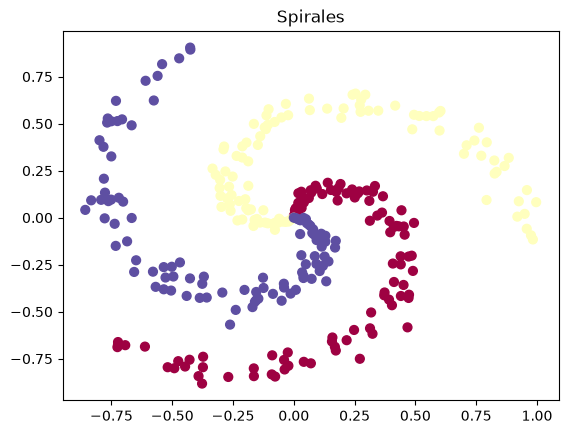

In [3]:
N = 100  # points par classe
D = 2    # dimensions
K = 3    # nombre de classes
X = np.zeros((N * K, D))
y = np.zeros(N * K, dtype='uint8')
for j in range(K):
    ix = range(N * j, N * (j + 1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
    y[ix] = j

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.title("Spirales")
plt.show()

## 2. Tenseurs + train_test_split (80/20)

In [4]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
X_train.shape, X_test.shape

(torch.Size([240, 2]), torch.Size([60, 2]))

## 3. Modele (lineaire + ReLU, sortie K classes)

In [5]:
class SpiralModel(nn.Module):
    def __init__(self, in_features=2, hidden=64, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model = SpiralModel(num_classes=K).to(device)
model

SpiralModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

## 4. Perte + optimiseur (multiclasse, Adam)

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
acc_fn = MulticlassAccuracy(num_classes=K).to(device)

## 5. Boucle d'entrainement et de test

In [7]:
epochs = 1000

for epoch in range(epochs):
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    acc = acc_fn(logits.argmax(dim=1), y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = acc_fn(test_logits.argmax(dim=1), y_test)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Loss {loss:.4f} Acc {acc*100:.2f}% | "
            f"Test Loss {test_loss:.4f} Test Acc {test_acc*100:.2f}%"
        )

print(f"\nAccuracy test finale: {test_acc*100:.2f}%")

Epoch    0 | Loss 1.0955 Acc 32.23% | Test Loss 0.9925 Test Acc 59.66%
Epoch   10 | Loss 0.5232 Acc 68.53% | Test Loss 0.5023 Test Acc 69.51%
Epoch   20 | Loss 0.1941 Acc 95.85% | Test Loss 0.1534 Test Acc 98.48%
Epoch   30 | Loss 0.0720 Acc 99.18% | Test Loss 0.0380 Test Acc 100.00%
Epoch   40 | Loss 0.0444 Acc 99.18% | Test Loss 0.0151 Test Acc 100.00%
Epoch   50 | Loss 0.0348 Acc 99.15% | Test Loss 0.0075 Test Acc 100.00%
Epoch   60 | Loss 0.0299 Acc 99.18% | Test Loss 0.0044 Test Acc 100.00%
Epoch   70 | Loss 0.0269 Acc 99.18% | Test Loss 0.0027 Test Acc 100.00%
Epoch   80 | Loss 0.0248 Acc 99.15% | Test Loss 0.0018 Test Acc 100.00%
Epoch   90 | Loss 0.0233 Acc 99.15% | Test Loss 0.0013 Test Acc 100.00%
Epoch  100 | Loss 0.0221 Acc 99.18% | Test Loss 0.0010 Test Acc 100.00%
Epoch  110 | Loss 0.0210 Acc 99.18% | Test Loss 0.0006 Test Acc 100.00%
Epoch  120 | Loss 0.0201 Acc 99.15% | Test Loss 0.0005 Test Acc 100.00%
Epoch  130 | Loss 0.0194 Acc 99.18% | Test Loss 0.0004 Test Acc 100

## 6. Frontieres de decision

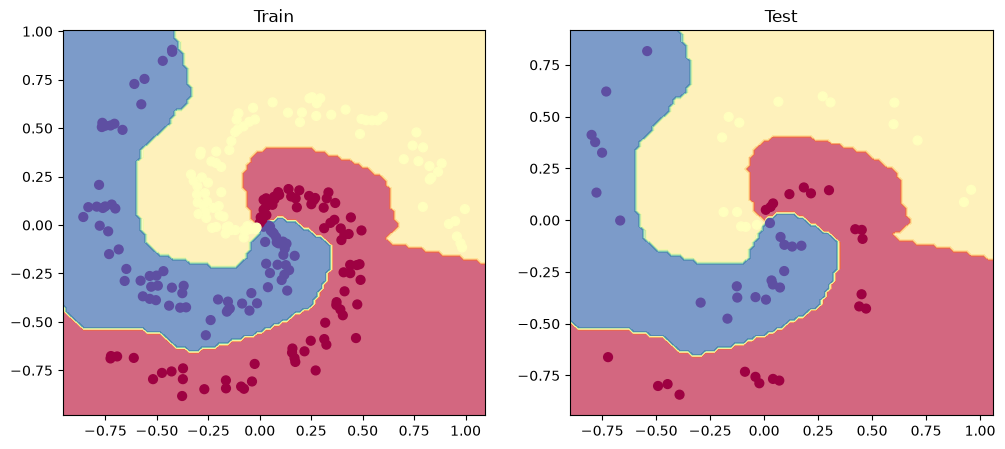

In [8]:
def plot_decision_boundary(model, X, y):
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101)
    )

    X_grid = torch.from_numpy(
        np.column_stack((xx.ravel(), yy.ravel()))
    ).float()

    model.eval()
    with torch.inference_mode():
        logits = model(X_grid)
    preds = logits.argmax(dim=1).reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap=plt.cm.Spectral, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
plt.show()